# Playground de Calibración Bayesiana con Optuna
Este notebook permite cargar las muestras de entrenamiento, realizar la división Train/Test Split (para evitar fugas de información) y graficar las Matrices de Confusión (tanto en cantidades como en porcentajes) para los conjuntos de Entrenamiento y Validación.

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# Compatibilidad de Pickle entre diferentes versiones de NumPy (1.x vs 2.x)
try:
    import numpy._core.numeric
except ModuleNotFoundError:
    import numpy.core as numpy_core
    import numpy.core.numeric as numpy_core_numeric
    sys.modules['numpy._core'] = numpy_core
    sys.modules['numpy._core.numeric'] = numpy_core_numeric

try:
    import numpy.core.numeric
except ModuleNotFoundError:
    import numpy._core as numpy_core
    import numpy._core.numeric as numpy_core_numeric
    sys.modules['numpy.core'] = numpy_core
    sys.modules['numpy.core.numeric'] = numpy_core_numeric

# Configurar rutas del proyecto
PROJECT_ROOT = Path("../../../..").resolve()
sys.path.append(str(PROJECT_ROOT))

from pipeline_v3.src import config
from pipeline_v3.calibration_and_diagnostics.modal_classification.calibration.bayes.optimizar_matrices_optuna import (
    build_vectorized_cache,
    evaluate_matrices_vectorized,
    MODOS,
    BASELINE_CERCANIA, BASELINE_VELOCIDAD, BASELINE_DISTANCIA, BASELINE_VELPROM
)

## 1. Cargar el Caché de Entrenamiento y realizar Train/Test Split
Cargamos las muestras de viajes completados por el ruteador y realizamos la misma división que en el script de optimización.

In [2]:
clean_csv_path = config.GPS_DIR / "Datos de MATLAB GPS Limpios.csv"
pkl_path = config.GPS_DIR / "datos_entrenamiento_ml.pkl"

print(f"Cargando archivo: {pkl_path}")
with open(pkl_path, "rb") as f:
    data_cache_raw = pickle.load(f)

print(f"Cargando mapeo de exclusión canónico: {clean_csv_path}")
df_clean = pd.read_csv(clean_csv_path)
canonical_modes = {}
mixed_trips = []
empty_trips = []

for (caid, num_trip), sub in df_clean.groupby(['caid', 'num_trip']):
    try:
        trip_num_str = str(int(float(num_trip)))
    except:
        trip_num_str = str(num_trip).strip()
    key = f"{str(caid).strip()}_{trip_num_str}"
    modes = sub['mode_of_transport'].dropna().unique()
    modes = [m.strip().lower() for m in modes if str(m).strip()]
    
    if len(modes) == 0:
        canonical_modes[key] = "empty_label"
        empty_trips.append(key)
    elif len(modes) > 1:
        canonical_modes[key] = "mixed_label"
        mixed_trips.append(key)
    else:
        canonical_modes[key] = modes[0]

print(f"Total trayectorias físicas: {len(canonical_modes)}")
print(f"Excluyendo {len(mixed_trips)} viajes mixtos y {len(empty_trips)} vacíos.")

data_cache = []
for item in data_cache_raw:
    parts = item["trip_id"].split("-")
    caid_trip = parts[0]
    canonical_label = canonical_modes.get(caid_trip)
    
    if not canonical_label or canonical_label in ["mixed_label", "empty_label"]:
        continue
        
    item["label"] = canonical_label.capitalize()
    data_cache.append(item)

print(f"Total de muestras de entrenamiento canónicas: {len(data_cache)}")

# Realizar la división Train/Test Split agrupando por viaje físico
TEST_SIZE = 0.2
SEED = 42

trip_groups = {}
for item in data_cache:
    base_id = item["trip_id"].split("-")[0]
    if base_id not in trip_groups:
        trip_groups[base_id] = []
    trip_groups[base_id].append(item)
    
unique_trips = list(trip_groups.keys())
unique_trips.sort()
np.random.seed(SEED)
np.random.shuffle(unique_trips)

n_total_trips = len(unique_trips)
n_test = max(1, int(n_total_trips * TEST_SIZE))
n_train = n_total_trips - n_test

train_trips = set(unique_trips[:n_train])
test_trips = set(unique_trips[n_train:])

train_cache = [item for base_id, items in trip_groups.items() if base_id in train_trips for item in items]
val_cache = [item for base_id, items in trip_groups.items() if base_id in test_trips for item in items]

print(f"\n▶ División Train/Test Split realizada:")
print(f"   Total viajes físicos: {n_total_trips} | Entrenamiento: {len(train_trips)} viajes ({len(train_cache)} muestras) | Validación: {len(test_trips)} viajes ({len(val_cache)} muestras)")

Cargando archivo: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0\Inputs\GPS User Data\datos_entrenamiento_ml.pkl
Cargando mapeo de exclusión canónico: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0\Inputs\GPS User Data\Datos de MATLAB GPS Limpios.csv
Total trayectorias físicas: 139
Excluyendo 15 viajes mixtos y 0 vacíos.
Total de muestras de entrenamiento canónicas: 367

▶ División Train/Test Split realizada:
   Total viajes físicos: 66 | Entrenamiento: 53 viajes (303 muestras) | Validación: 13 viajes (64 muestras)


## 2. Construir Caché Vectorizado y Reportar Estadísticas
Preparamos los cachés vectorizados de entrenamiento y validación para la evaluación rápida con NumPy.

In [3]:
train_vcache = build_vectorized_cache(train_cache)
val_vcache = build_vectorized_cache(val_cache) if val_cache else None

total_train_pings = sum(len(trip["hypotheses"][0]["idx_c"]) for trip in train_vcache) if train_vcache else 0
total_val_pings = sum(len(trip["hypotheses"][0]["idx_c"]) for trip in val_vcache) if val_vcache else 0

print(f"Cache de Entrenamiento: {len(train_vcache)} viajes, {total_train_pings} pings.")
if val_vcache:
    print(f"Cache de Validación: {len(val_vcache)} viajes, {total_val_pings} pings.")

Cache de Entrenamiento: 208 viajes, 14302 pings.
Cache de Validación: 52 viajes, 4224 pings.


## 3. Cargar Matrices (Baseline vs Óptimas)
Si ya corriste la sintonización con Optuna, se cargarán las matrices óptimas desde el archivo JSON de salida. De lo contrario, se usarán las del paper original.

In [4]:
json_path = Path("matrices_optimas.json")

if json_path.exists():
    import json
    with open(json_path, "r", encoding="utf-8") as f:
        opt_data = json.load(f)
    print(f"Cargadas matrices óptimas desde {json_path} (Generadas el: {opt_data.get('timestamp')})")
    Cercania = np.array(opt_data["matrices"]["Cercania"])
    Velocidad = np.array(opt_data["matrices"]["Velocidad"])
    Distancia = np.array(opt_data["matrices"]["Distancia"])
    Velprom = np.array(opt_data["matrices"]["Velprom"])
    
    val_metric = opt_data.get("metric_optimized", "balanced_accuracy")
    val_score = opt_data.get(val_metric, 0.0)
    print(f"Métrica de optimización ({val_metric}): {val_score:.4f}")
else:
    print("No se encontró matrices_optimas.json. Cargando matrices Baseline del paper original.")
    Cercania = BASELINE_CERCANIA
    Velocidad = BASELINE_VELOCIDAD
    Distancia = BASELINE_DISTANCIA
    Velprom = BASELINE_VELPROM

Cargadas matrices óptimas desde matrices_optimas.json (Generadas el: 2026-07-15T04:08:06.829889)
Métrica de optimización (balanced_accuracy): 0.4171


## 4. Evaluar y Graficar Matrices de Confusión (Entrenamiento vs Validación)
Evaluamos las predicciones del clasificador aplicando clipeo de seguridad y mostramos los reportes y gráficas para cada subconjunto.


       REPORTE DE CLASIFICACIÓN - ENTRENAMIENTO
              precision    recall  f1-score   support

       Carro       0.68      0.88      0.77       128
         Bus       0.00      0.00      0.00        32
       Metro       0.00      0.00      0.00        20
     Caminar       0.63      0.79      0.70        28

    accuracy                           0.65       208
   macro avg       0.33      0.42      0.37       208
weighted avg       0.51      0.65      0.57       208



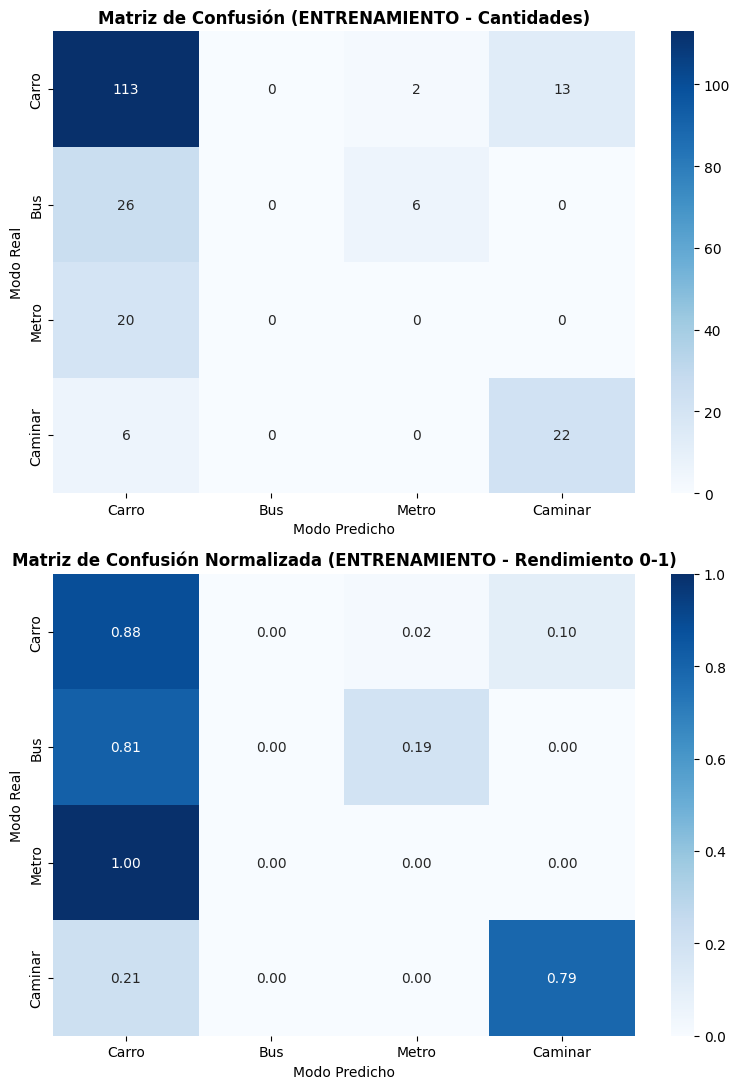


       REPORTE DE CLASIFICACIÓN - VALIDACIÓN
              precision    recall  f1-score   support

       Carro       0.61      0.97      0.75        32
         Bus       0.00      0.00      0.00        16
       Metro       0.00      0.00      0.00         4
     Caminar       0.00      0.00      0.00         0

    accuracy                           0.60        52
   macro avg       0.15      0.24      0.19        52
weighted avg       0.37      0.60      0.46        52



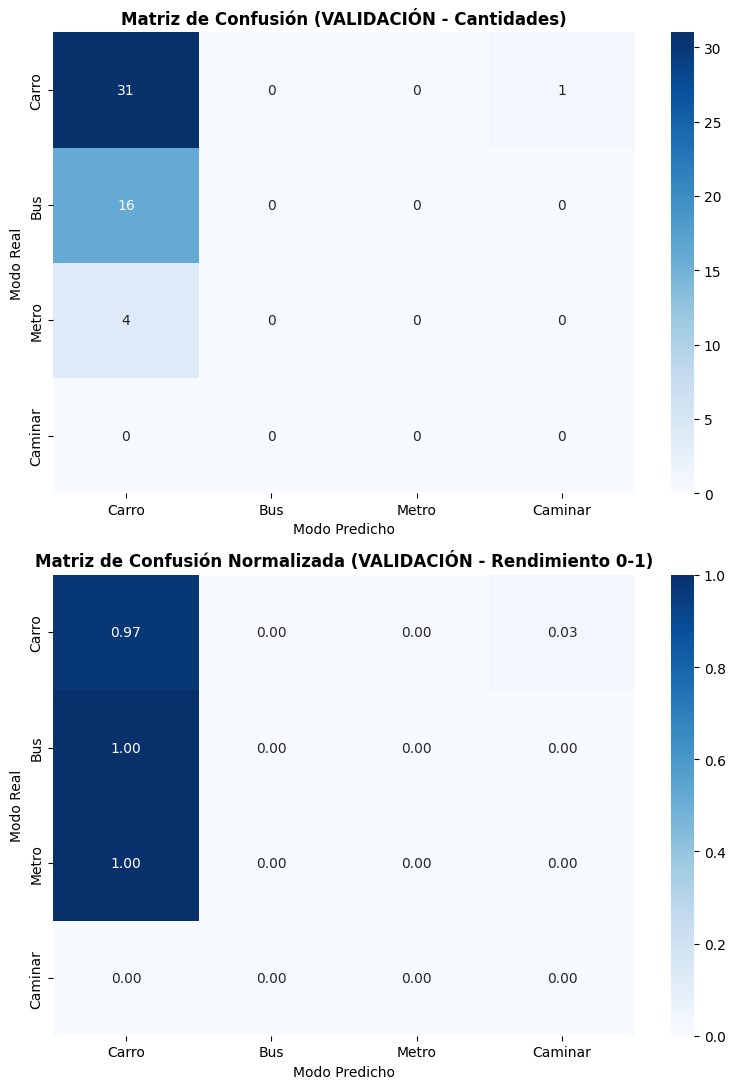

In [5]:
MODE_TO_IDX = {m: i for i, m in enumerate(MODOS)}

def get_predictions(vcache, Cercania, Velocidad, Distancia, Velprom):
    y_true = []
    y_pred = []
    
    # Regularización de seguridad (clipeo 0.01 - 0.99 y re-normalización)
    Cercania_reg = np.clip(Cercania, 0.01, 0.99)
    Cercania_reg = Cercania_reg / Cercania_reg.sum(axis=1, keepdims=True)

    Velocidad_reg = np.clip(Velocidad, 0.01, 0.99)
    Velocidad_reg = Velocidad_reg / Velocidad_reg.sum(axis=1, keepdims=True)

    Distancia_reg = np.clip(Distancia, 0.01, 0.99)
    Distancia_reg = Distancia_reg / Distancia_reg.sum(axis=1, keepdims=True)

    Velprom_reg = np.clip(Velprom, 0.01, 0.99)
    Velprom_reg = Velprom_reg / Velprom_reg.sum(axis=1, keepdims=True)
    
    THRESHOLD_BUS = 0.80

    for trip in vcache:
        label = trip["label"]
        label_idx = MODE_TO_IDX[label]
        
        scores = {}
        probs_by_mode = {}
        idx_c_by_mode = {}
        
        for hyp in trip["hypotheses"]:
            modo_hip = hyp["modo_hipotesis"]
            idx_c = hyp["idx_c"]
            idx_v = hyp["idx_v"]
            idx_d = hyp["idx_d"]
            idx_vp = hyp["idx_vp"]
            
            # Multiplicación bayesiana punto a punto
            P_unnorm = Cercania_reg[idx_c] * Velocidad_reg[idx_v] * Distancia_reg[idx_d] * Velprom_reg[idx_vp]
            row_sums = P_unnorm.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0.0] = 1.0
            P_norm = P_unnorm / row_sums
            
            mean_probs = P_norm.mean(axis=0)
            probs_by_mode[modo_hip] = mean_probs
            idx_c_by_mode[modo_hip] = idx_c
            
            if modo_hip == "caminar":
                scores["Caminar"] = mean_probs[3]
            elif modo_hip == "metro":
                scores["Metro"] = mean_probs[2]
            elif modo_hip in ["carro", "bus"]:
                scores["Carro"] = mean_probs[0]
                
        if not scores:
            pred = "Caminar"
        else:
            best_mode = max(scores, key=scores.get)
            pred = best_mode
            
            if best_mode == "Carro":
                road_hip = None
                for hip in ["carro", "bus"]:
                    if hip in probs_by_mode:
                        road_hip = hip
                        break
                if road_hip is not None:
                    road_probs = probs_by_mode[road_hip]
                    road_idx_c = idx_c_by_mode[road_hip]
                    
                    fraction_near_bus = np.mean(road_idx_c == 1)
                    if road_probs[1] > road_probs[0] and fraction_near_bus >= THRESHOLD_BUS:
                        pred = "Bus"
                    else:
                        pred = "Carro"
                        
        y_true.append(label_idx)
        y_pred.append(MODE_TO_IDX[pred])
        
    return np.array(y_true), np.array(y_pred)

# EVALUAR AMBOS SETS (Entrenamiento y Validación)
for name, vcache in [("ENTRENAMIENTO", train_vcache), ("VALIDACIÓN", val_vcache)]:
    if vcache is None:
        continue
        
    y_true_arr, y_pred_arr = get_predictions(vcache, Cercania, Velocidad, Distancia, Velprom)
    
    print(f"\n=======================================================")
    print(f"       REPORTE DE CLASIFICACIÓN - {name}")
    print(f"=======================================================")
    print(classification_report(y_true_arr, y_pred_arr, target_names=MODOS, zero_division=0))
    
    # Graficar Matrices de Confusión
    cm = confusion_matrix(y_true_arr, y_pred_arr)
    cm_norm = confusion_matrix(y_true_arr, y_pred_arr, normalize='true')
    
    fig, axes = plt.subplots(2, 1, figsize=(8, 11))
    
    # 1. Matriz Absoluta
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=MODOS, yticklabels=MODOS, ax=axes[0])
    axes[0].set_title(f"Matriz de Confusión ({name} - Cantidades)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Modo Real", fontsize=10)
    axes[0].set_xlabel("Modo Predicho", fontsize=10)
    
    # 2. Matriz Normalizada
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=MODOS, yticklabels=MODOS, ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f"Matriz de Confusión Normalizada ({name} - Rendimiento 0-1)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Modo Real", fontsize=10)
    axes[1].set_xlabel("Modo Predicho", fontsize=10)
    
    plt.tight_layout()
    plt.show()